# Question 1: Load and Visualize Time Series Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

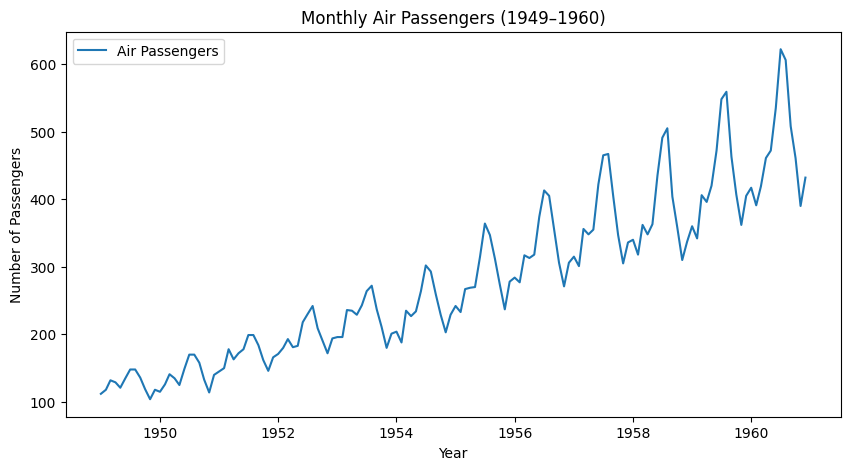

In [2]:
# Plot time series
plt.figure(figsize=(10,5))
plt.plot(df['Passengers'], label='Air Passengers')
plt.title("Monthly Air Passengers (1949–1960)")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()

# Question 2: Check Missing Values and Summary Stats

In [3]:
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())


Missing Values:
 Passengers    0
dtype: int64

Summary Statistics:
        Passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000


# Question 3: Decompose the Time Series

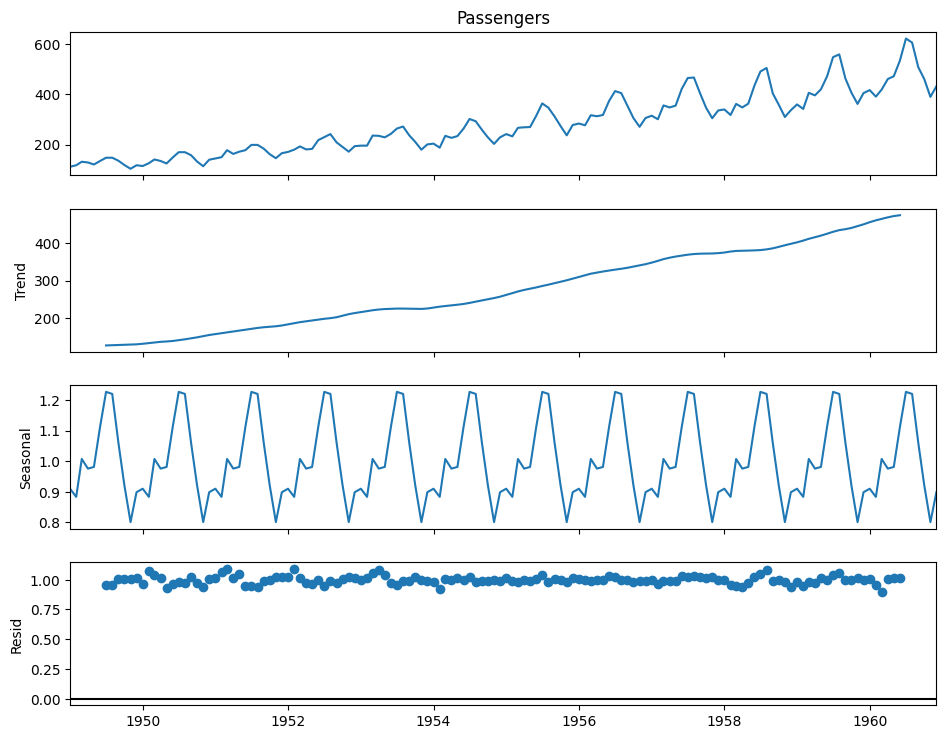

In [4]:
decomposition = seasonal_decompose(df['Passengers'], model='multiplicative')
fig = decomposition.plot()
fig.set_size_inches(10,8)
plt.show()

# Question 4: Check Stationarity with Augmented Dickey-Fuller Test

In [5]:
adf_result = adfuller(df['Passengers'])
print("\nADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])
if adf_result[1] <= 0.05:
    print("The series is stationary.")
else:
    print("The series is NOT stationary.")


ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641
Critical Values: {'1%': np.float64(-3.4816817173418295), '5%': np.float64(-2.8840418343195267), '10%': np.float64(-2.578770059171598)}
The series is NOT stationary.


# Question 5: Split Dataset into Train and Test (80/20)

In [6]:
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

In [7]:
print("\nTrain size:", len(train))
print("Test size:", len(test))


Train size: 115
Test size: 29


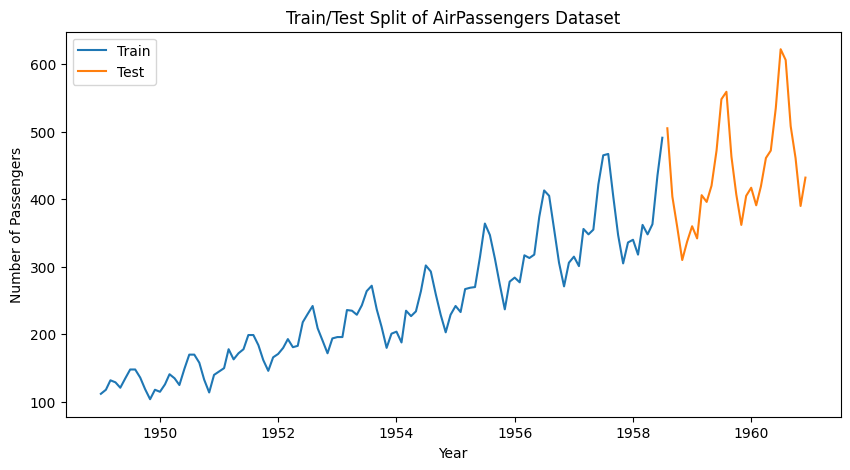

In [8]:
# Plot train/test split
plt.figure(figsize=(10,5))
plt.plot(train['Passengers'], label='Train')
plt.plot(test['Passengers'], label='Test')
plt.title("Train/Test Split of AirPassengers Dataset")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()